In [ ]:
pip install pandas matplotlib prophet

In [3]:
import pandas as pd
import io

data = """Date,Sales
2025-01-01,100
2025-01-02,120
2025-01-03,150
2025-01-04,130
2025-01-05,170
2025-01-06,180
2025-01-07,200
2025-01-08,190
2025-01-09,220
2025-01-10,250"""

df_sales = pd.read_csv(io.StringIO(data))
display(df_sales.head())

,Date,Sales
0,2025-01-01,100
1,2025-01-02,120
2,2025-01-03,150
3,2025-01-04,130
4,2025-01-05,170


INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 7.


           ds        yhat
35 2025-02-05  627.554359
36 2025-02-06  642.523377
37 2025-02-07  657.492396
38 2025-02-08  672.461414
39 2025-02-09  687.430432


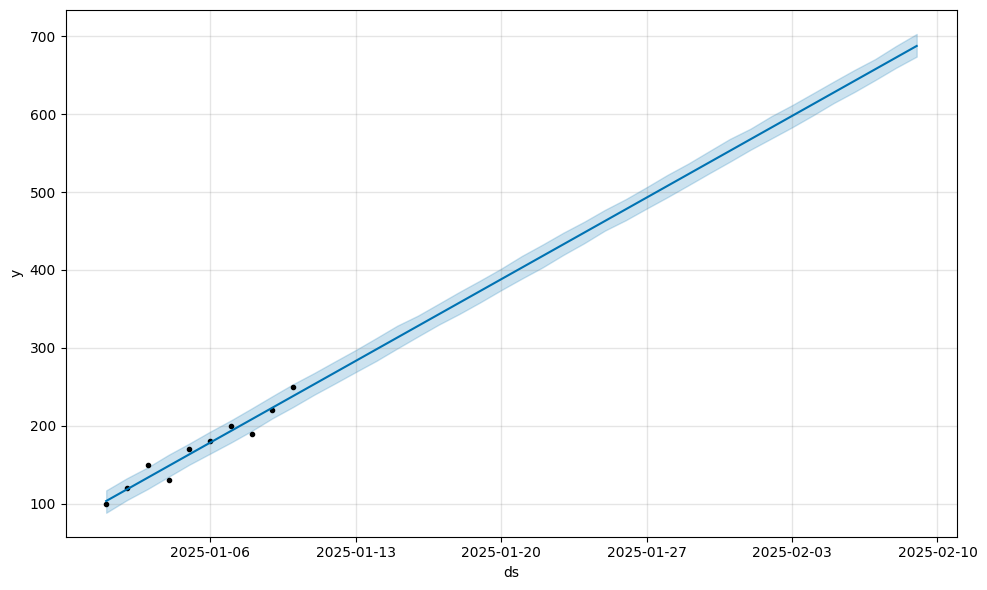

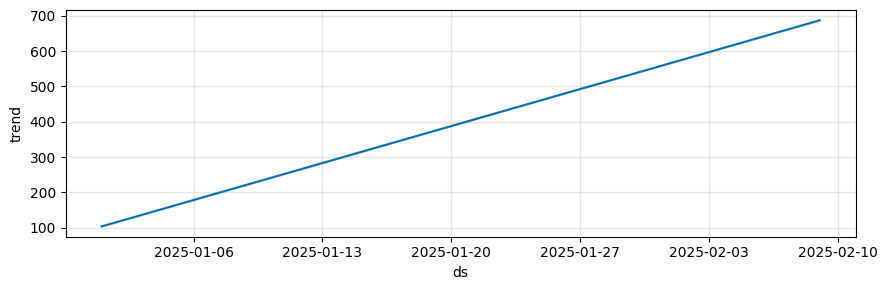

In [5]:
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt

# Use the df_sales DataFrame loaded previously
df = df_sales.copy() # Create a copy to avoid modifying the original df_sales

# Rename columns for Prophet
df = df.rename(columns={'Date': 'ds', 'Sales': 'y'})

# Convert date column (already done if df_sales was created correctly, but good to be explicit)
df['ds'] = pd.to_datetime(df['ds'])

# Train model
model = Prophet()
model.fit(df)

# Predict next 30 days
future = model.make_future_dataframe(periods=30)

forecast = model.predict(future)

# Display predictions
print(forecast[['ds', 'yhat']].tail())

# Plot forecast
fig1 = model.plot(forecast)
plt.show()

# Plot forecast components
fig2 = model.plot_components(forecast)
plt.show()